## 0. Import & Initialization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.optim as optim

## 1. Define the Himmelblau Function

In [2]:
T_TEMP = 20.0            # Temperature for the distribution

# 1. Define the Himmelblau Function
def himmelblau(x):
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

# 2. Define the Log-Probability (Target Distribution)
# We use log-probability for numerical stability in MCMC later
def log_prob_himmelblau(x, T=1.0):
    # x is a numpy array of shape (..., 2)
    f_val = (x[..., 0]**2 + x[..., 1] - 11)**2 + (x[..., 0] + x[..., 1]**2 - 7)**2
    return -f_val / T

def log_prob_himmelblau_torch(x, T=1.0):
    """
    PyTorch-compatible log probability for Himmelblau function.
    x: torch tensor of shape (..., 2)
    """
    # Ensure x is a tensor
    if not torch.is_tensor(x):
        x = torch.tensor(x, dtype=torch.float32)
        
    term1 = (x[..., 0]**2 + x[..., 1] - 11)**2
    term2 = (x[..., 0] + x[..., 1]**2 - 7)**2
    f_val = term1 + term2
    
    return -f_val / T

## 2. Visualize the Function

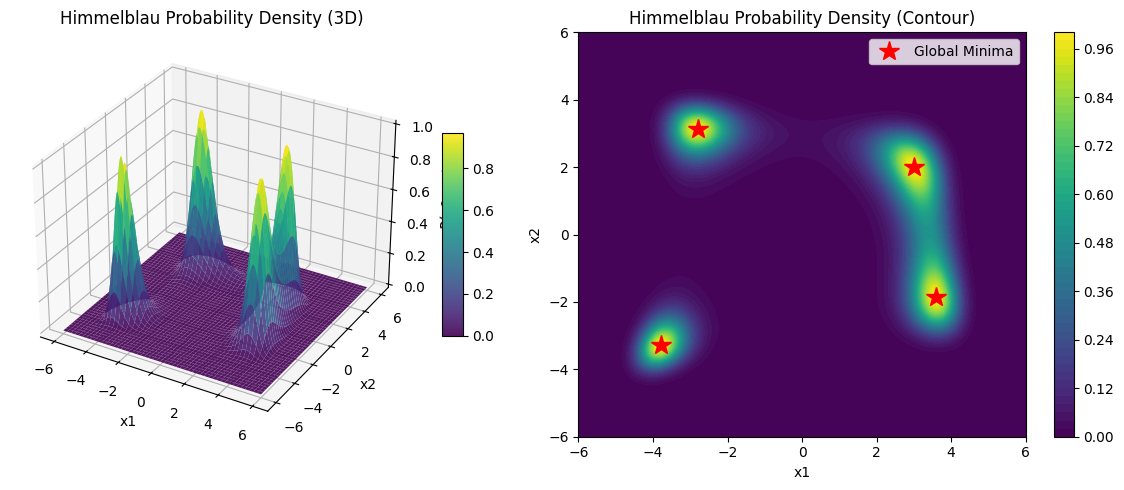

In [3]:
# 3. Create a Grid for Visualization
x_range = np.linspace(-6, 6, 400)
y_range = np.linspace(-6, 6, 400)
X, Y = np.meshgrid(x_range, y_range)
pos = np.dstack((X, Y)) # Shape: (400, 400, 2)

# Calculate Z values (Probability Density)
Z = np.exp(log_prob_himmelblau(pos, T=T_TEMP))

# 4. Plotting
fig = plt.figure(figsize=(12, 5))

# Plot 1: 3D Surface Plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title('Himmelblau Probability Density (3D)')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('P(x1, x2)')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Plot 2: Contour Plot (Top-down view)
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, Z, levels=50, cmap='viridis')
ax2.set_title('Himmelblau Probability Density (Contour)')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
fig.colorbar(contour, ax=ax2)

# Mark the 4 known minima for reference
minima = np.array([
    [3.0, 2.0],
    [-2.805118, 3.131312],
    [-3.779310, -3.283186],
    [3.584428, -1.848126]
])
ax2.plot(minima[:, 0], minima[:, 1], 'r*', markersize=15, label='Global Minima')
ax2.legend()

plt.tight_layout()
plt.savefig('../assets/himmelblau_density.png', dpi=300)
plt.show()

## 3. Classical MCMC Sampling (Metropolis-Hastings)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Configuration ---
N_SAMPLES = 10000       # Total number of steps
BURN_IN = 1000          # Steps to discard at the start
PROPOSAL_STD = 1      # Standard deviation of the random walk proposal

In [5]:
# --- 2. Classical Random Walk Metropolis Function ---
def classical_mh(log_prob_fn, n_samples, initial_state, prop_std):
    """
    Runs Classical Random Walk Metropolis.
    """
    dim = len(initial_state)
    samples = np.zeros((n_samples, dim))
    current_state = np.array(initial_state, dtype=float)
    
    # Calculate initial log probability
    current_log_prob = log_prob_fn(current_state, T=T_TEMP)
    
    accepted_count = 0
    
    for i in range(n_samples):
        # 1. Propose: Add Gaussian noise
        # q(x* | x_t) = N(x_t, prop_std^2 * I)
        proposal = current_state + np.random.normal(0, prop_std, size=dim)
        
        # 2. Calculate Log Probability of Proposal
        proposal_log_prob = log_prob_fn(proposal, T=T_TEMP)
        
        # 3. Acceptance Ratio (Log Space)
        # Since proposal is symmetric, Hastings correction is 0
        log_alpha = proposal_log_prob - current_log_prob
        
        # 4. Accept/Reject
        if np.log(np.random.rand()) < log_alpha:
            current_state = proposal
            current_log_prob = proposal_log_prob
            accepted_count += 1
            
        # 5. Store Sample
        samples[i] = current_state
        
    acceptance_rate = accepted_count / n_samples
    return samples, acceptance_rate

In [6]:
# --- 3. Run Classical MH ---
print("Running Classical MCMC...")
initial_state = [0.0, 0.0] # Start at origin (low probability region)
samples_classical, acc_rate_classical = classical_mh(
    log_prob_himmelblau, 
    N_SAMPLES, 
    initial_state, 
    PROPOSAL_STD
)

print(f"Classical Acceptance Rate: {acc_rate_classical:.2f}")

Running Classical MCMC...
Classical Acceptance Rate: 0.37


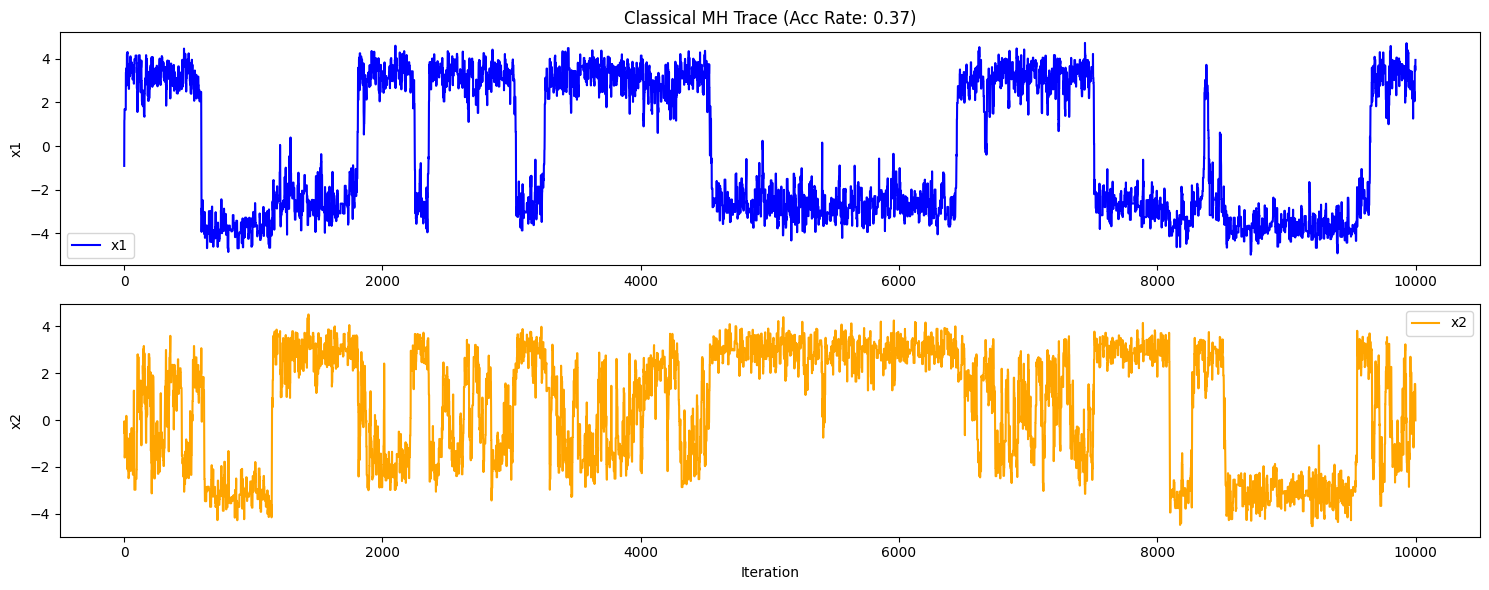

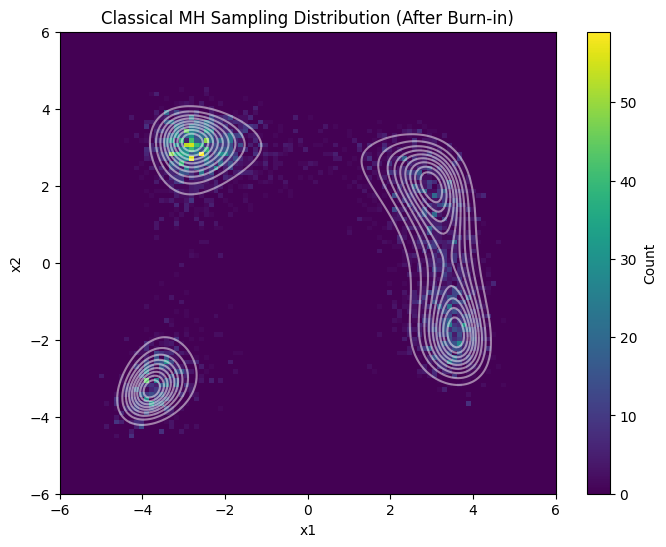

In [7]:
# --- 4. Visualization of Classical Results ---

# A. Trace Plot (How the values change over time)
fig, axes = plt.subplots(2, 1, figsize=(15, 6))
axes[0].plot(samples_classical[:, 0], label='x1', color='blue')
axes[0].set_ylabel('x1')
axes[0].legend()
axes[0].set_title(f'Classical MH Trace (Acc Rate: {acc_rate_classical:.2f})')

axes[1].plot(samples_classical[:, 1], label='x2', color='orange')
axes[1].set_ylabel('x2')
axes[1].set_xlabel('Iteration')
axes[1].legend()

plt.tight_layout()
plt.show()

# B. 2D Histogram (Where did the sampler go?)
plt.figure(figsize=(8, 6))
plt.hist2d(samples_classical[BURN_IN:, 0], samples_classical[BURN_IN:, 1], 
           bins=100, cmap='viridis', range=[[-6, 6], [-6, 6]])
plt.colorbar(label='Count')
plt.title('Classical MH Sampling Distribution (After Burn-in)')
plt.xlabel('x1')
plt.ylabel('x2')

# Overlay the true contours for reference
x_range = np.linspace(-6, 6, 200)
y_range = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = np.exp(log_prob_himmelblau(np.dstack((X, Y)), T=T_TEMP))
plt.contour(X, Y, Z, levels=10, colors='white', alpha=0.5)

plt.show()

## 3. MH Sampling with Learned Proposals (NeuralMH)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [9]:
class AdaptiveStepNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super(AdaptiveStepNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, input_dim) # Output log_std for each dimension
        )
        
        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        """
        x: tensor of shape (batch, input_dim)
        returns: log_std (batch, input_dim)
        Note: Mean is implicitly 0 (centered at current state)
        """
        log_std = self.net(x)
        # Clamp to prevent extreme variances
        # std range: [exp(-3), exp(2)] approx [0.05, 7.4]
        log_std = torch.clamp(log_std, min=-3)
        return log_std

In [10]:
def compute_gaussian_entropy(log_std):
    """
    Compute entropy of a diagonal Gaussian.
    H = 0.5 * sum(log(2*pi*e*std^2))
    """
    # log_std is (batch, dim)
    dim = log_std.shape[1]
    # Entropy per dimension: 0.5 * (log(2*pi) + 1 + 2*log_std)
    entropy_per_dim = 0.5 * (np.log(2 * np.pi) + 1 + 2 * log_std)
    # Sum over dimensions
    total_entropy = entropy_per_dim.sum(dim=1)
    return total_entropy

def variational_loss(log_prob_target, log_std, beta=1.0):
    """
    Compute the Variational Loss:
    L = -log P(x*) - beta * H(Q)
    
    log_prob_target: log P(x*) for the proposed samples
    log_std: log standard deviation output by the network
    beta: entropy regularization weight
    """
    entropy = compute_gaussian_entropy(log_std)
    loss = -log_prob_target - beta * entropy
    # print(f"Mean Log Prob: {log_prob_target.mean().item():.4f}, Mean Entropy: {entropy.mean().item():.4f}, Loss: {loss.mean().item():.4f}")
    return loss.mean()

In [11]:
def neural_mh_step_variational(current_state, log_prob_fn, model, optimizer, 
                                     beta=1.0, min_std=0.1, T=20.0):
    """
    Fixed Variational Adaptive MCMC with Differentiable Sampling.
    """
    dim = len(current_state)
    current_tensor = torch.tensor(current_state, dtype=torch.float32).unsqueeze(0)
    
    # 1. Get log_std from network
    log_std_fwd = model(current_tensor)
    std_fwd = torch.exp(log_std_fwd)
    std_fwd = torch.clamp(std_fwd, min=min_std) # Enforce min std
    
    # 2. Differentiable Proposal (Reparameterization Trick)
    # z ~ N(0, 1), then x* = x_t + std * z
    # rsample allows gradients to flow through std
    dist_fwd = torch.distributions.Normal(torch.zeros_like(current_tensor), std_fwd)
    z = dist_fwd.rsample() 
    proposal_tensor = current_tensor + z
    
    # Detach proposal for the actual M-H decision (we don't want gradients 
    # affecting the accept/reject logic itself, only the training loss)
    proposal_np = proposal_tensor.detach().numpy()[0]
    
    # 3. Compute Acceptance Ratio (WITH Hastings Correction)
    current_log_p = log_prob_fn(current_state, T=T)
    proposal_log_p_np = log_prob_fn(proposal_np, T=T)
    
    # Log Target Ratio
    log_target_ratio = proposal_log_p_np - current_log_p
    
    # Hastings Correction
    with torch.no_grad():
        # Forward: q(x* | x_t)
        log_q_fwd = dist_fwd.log_prob(proposal_tensor).sum(dim=1).item()
        
        # Backward: q(x_t | x*)
        # We need std at the PROPOSED state
        log_std_bwd = model(proposal_tensor.detach()) # Detach to avoid double-backprop issues
        std_bwd = torch.exp(log_std_bwd)
        std_bwd = torch.clamp(std_bwd, min=min_std)
        
        dist_bwd = torch.distributions.Normal(proposal_tensor.detach(), std_bwd)
        log_q_bwd = dist_bwd.log_prob(current_tensor).sum(dim=1).item()
    
    log_correction = log_q_bwd - log_q_fwd
    log_alpha = min(log_target_ratio + log_correction, 0.0)
    
    # 4. Accept/Reject
    accepted = np.log(np.random.rand()) < log_alpha
    next_state = proposal_np if accepted else current_state
    
    # 5. Training Step (Variational Update)
    optimizer.zero_grad()
    
    # Compute loss using the DIFFERENTIABLE proposal_tensor
    # We use the PyTorch version of log_prob here so gradients flow!
    proposal_log_p_torch = log_prob_fn(proposal_tensor, T=T)
    
    loss = variational_loss(proposal_log_p_torch, log_std_fwd, beta=beta)
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    return next_state, accepted, loss.item()

In [14]:
def run_variational_mcmc(log_prob_fn, n_samples, initial_state, 
                         warmup_steps=2000, prop_std_init=1.0,
                         hidden_dim=64, lr=1e-3, beta=1.0,
                         min_std=0.1, T=20.0):
    """
    Run Variational Adaptive MCMC.
    """
    dim = len(initial_state)
    samples = np.zeros((n_samples, dim))
    
    # Initialize model
    model = AdaptiveStepNet(input_dim=dim, hidden_dim=hidden_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    current_state = np.array(initial_state, dtype=float)
    accepted_count = 0
    loss_history = []
    std_history = [] # To monitor how step-size evolves
    
    print("Starting Variational Adaptive MCMC...")
    
    for i in range(n_samples):
        # Warm-up: Classical Random Walk
        if i < warmup_steps:
            proposal = current_state + np.random.normal(0, prop_std_init, size=dim)
            current_log_p = log_prob_fn(current_state, T=T)
            proposal_log_p = log_prob_fn(proposal, T=T)
            log_alpha = proposal_log_p - current_log_p
            
            if np.log(np.random.rand()) < log_alpha:
                current_state = proposal
                accepted_count += 1
        else:
            # Variational Adaptive Step
            current_state, accepted, loss = neural_mh_step_variational(
                current_state, log_prob_fn, model, optimizer,
                beta=beta, min_std=min_std, T=T
            )
            if accepted:
                accepted_count += 1
            loss_history.append(loss)
            
            # Monitor predicted std (average over dims)
            with torch.no_grad():
                curr_tensor = torch.tensor(current_state, dtype=torch.float32).unsqueeze(0)
                pred_log_std = model(curr_tensor)
                avg_std = np.mean(np.exp(pred_log_std.numpy()[0]))
                std_history.append(avg_std)
        
        samples[i] = current_state
        
        if (i+1) % 1000 == 0:
            acc_rate = accepted_count / (i+1)
            print(f"Step {i+1}/{n_samples}, Acc Rate: {acc_rate:.3f}")
            if loss_history:
                print(f"  Recent Loss: {loss_history[-1]:.4f}")
                print(f"  Avg Loss (last 100): {np.mean(loss_history[-100:]):.4f}")
                print(f"  Avg Predicted Std: {np.mean(std_history[-100:]):.4f}")
    
    overall_acc_rate = accepted_count / n_samples
    print(f"\nComplete. Overall Acceptance Rate: {overall_acc_rate:.3f}")
    
    return samples, overall_acc_rate, model, loss_history, std_history

# --- Execute ---

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("="*50)
print("Running Variational Adaptive MCMC")
print("="*50)

N_SAMPLES = 10000
INITIAL_STATE = [0.0, 0.0]

# Try beta=1.0 first. If variance collapses, increase to 5.0 or 10.0
samples_variational, acc_rate_variational, var_model, loss_hist_var, std_hist_var = run_variational_mcmc(
    log_prob_himmelblau_torch,
    n_samples=N_SAMPLES,
    initial_state=INITIAL_STATE,
    warmup_steps=2000,
    prop_std_init=1.0,
    hidden_dim=64,
    lr=1e-5,
    beta=1.0,       # Start with theoretical value
    min_std=0.1,
    T=T_TEMP
)

Running Variational Adaptive MCMC
Starting Variational Adaptive MCMC...
Step 1000/10000, Acc Rate: 0.367
Step 2000/10000, Acc Rate: 0.400
Step 3000/10000, Acc Rate: 0.578
  Recent Loss: 742.3507
  Avg Loss (last 100): 129.3348
  Avg Predicted Std: 0.7556
Step 4000/10000, Acc Rate: 0.671
  Recent Loss: 72.9339
  Avg Loss (last 100): 123.1416
  Avg Predicted Std: 0.9305
Step 5000/10000, Acc Rate: 0.715
  Recent Loss: 10.1195
  Avg Loss (last 100): 36.1611
  Avg Predicted Std: 0.7836
Step 6000/10000, Acc Rate: 0.735
  Recent Loss: 76.7576
  Avg Loss (last 100): 71.9679
  Avg Predicted Std: 0.7770
Step 7000/10000, Acc Rate: 0.757
  Recent Loss: 9.5473
  Avg Loss (last 100): 23.9715
  Avg Predicted Std: 0.9696
Step 8000/10000, Acc Rate: 0.768
  Recent Loss: 0.7475
  Avg Loss (last 100): 9.9771
  Avg Predicted Std: 1.0694
Step 9000/10000, Acc Rate: 0.775
  Recent Loss: 4.8553
  Avg Loss (last 100): 4.1149
  Avg Predicted Std: 1.0632
Step 10000/10000, Acc Rate: 0.776
  Recent Loss: 2.2257
  A

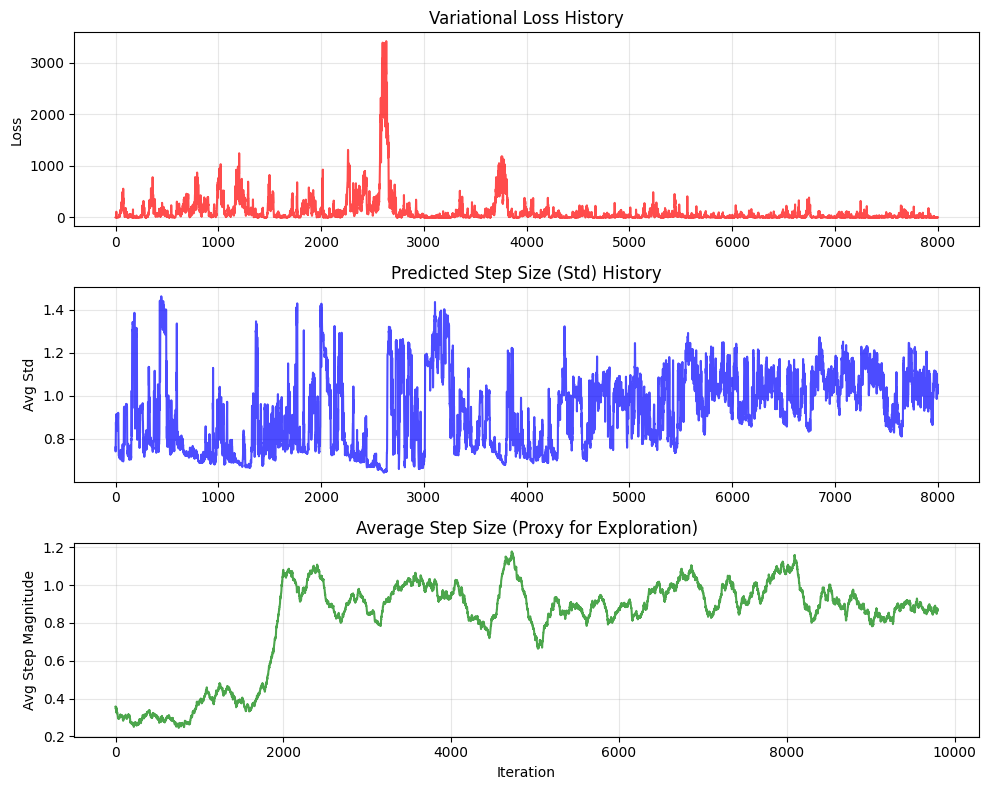

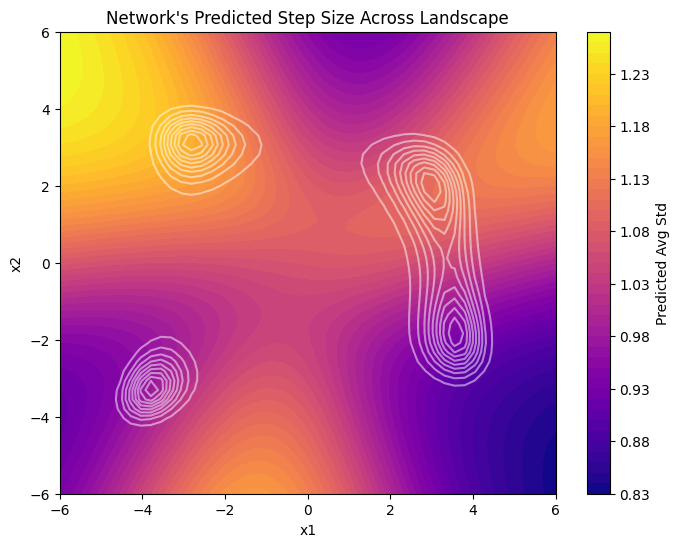

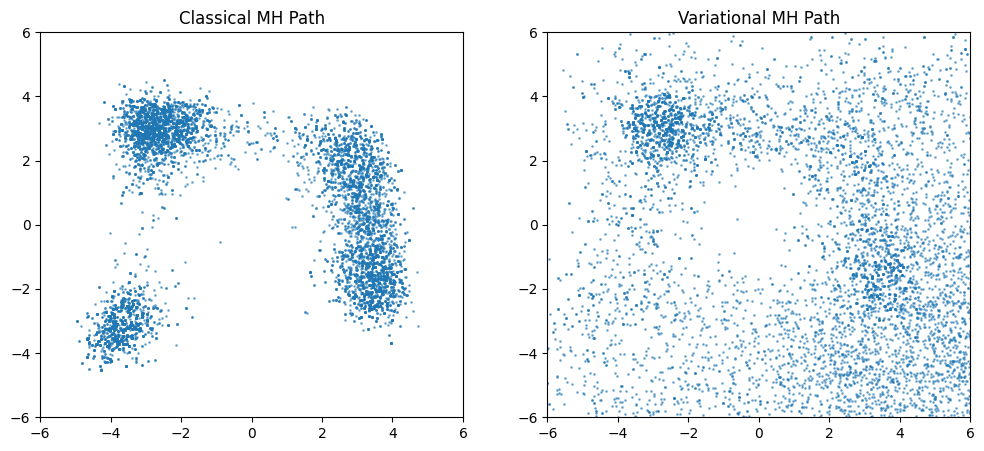

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Loss & Std History ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

# Plot Loss
axes[0].plot(loss_hist_var, color='red', alpha=0.7)
axes[0].set_title('Variational Loss History')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

# Plot Predicted Standard Deviation (Average over dimensions)
axes[1].plot(std_hist_var, color='blue', alpha=0.7)
axes[1].set_title('Predicted Step Size (Std) History')
axes[1].set_ylabel('Avg Std')
axes[1].grid(alpha=0.3)

# Plot Acceptance Rate (Sliding Window)
window = 200
acc_rates = []
for i in range(window, len(samples_variational)):
    window_samples = samples_variational[i-window:i+1]
    # Calculate local acc rate by checking how many unique points vs total
    # Note: This is an approximation. For exact acc rate, we need to store flags.
    # Instead, let's just plot the trace volatility as a proxy for step size effectiveness
    diffs = np.diff(window_samples, axis=0)
    avg_step_size = np.mean(np.sqrt(np.sum(diffs**2, axis=1)))
    acc_rates.append(avg_step_size)

axes[2].plot(acc_rates, color='green', alpha=0.7)
axes[2].set_title('Average Step Size (Proxy for Exploration)')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Avg Step Magnitude')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- 2. State-Dependent Variance Map ---
# Let's see what std the network predicts across the entire 2D space
x_range = np.linspace(-6, 6, 50)
y_range = np.linspace(-6, 6, 50)
X, Y = np.meshgrid(x_range, y_range)
grid_points = np.dstack((X, Y)).reshape(-1, 2)

with torch.no_grad():
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    pred_log_std = var_model(grid_tensor)
    pred_std = np.exp(pred_log_std.numpy())
    avg_pred_std = np.mean(pred_std, axis=1).reshape(50, 50)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, avg_pred_std, levels=50, cmap='plasma')
plt.colorbar(label='Predicted Avg Std')
plt.title('Network\'s Predicted Step Size Across Landscape')
plt.xlabel('x1'); plt.ylabel('x2')

# Overlay true contours
Z = np.exp(log_prob_himmelblau(np.dstack((X, Y)), T=T_TEMP))
plt.contour(X, Y, Z, levels=10, colors='white', alpha=0.5)
plt.show()

# --- 3. Trace Comparison (Classical vs Variational) ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(samples_classical[:, 0], samples_classical[:, 1], '.', markersize=2, alpha=0.5)
plt.title('Classical MH Path')
plt.xlim(-6, 6); plt.ylim(-6, 6)

plt.subplot(1, 2, 2)
plt.plot(samples_variational[:, 0], samples_variational[:, 1], '.', markersize=2, alpha=0.5)
plt.title('Variational MH Path')
plt.xlim(-6, 6); plt.ylim(-6, 6)
plt.show()